# Logistic Regression Model 


In [30]:

import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [31]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [32]:

from src.preprocessing import basic_clean
from src.features import get_tfidf_features
from src.evaluate import evaluate_model

In [33]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [34]:

# File paths 

TRAIN_PATH = "../datasets/processed/train_split.csv"
VAL_PATH = "../datasets/processed/val_split.csv"
TEST_PATH = "../datasets/processed/test_split.csv"

MODEL_DIR = "../saved_models"

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "logistic_regression.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "logistic_regression_tfidf_vectorizer.pkl"
)

RESULTS_DIR = "../results"

RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "model_comparison.csv"
)

CONFUSION_MATRIX_DIR = os.path.join(
    RESULTS_DIR,
    "confusion_matrices"
)


In [35]:

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CONFUSION_MATRIX_DIR, exist_ok=True)

print("File paths are ready!")
print("Model directory:", MODEL_DIR)
print("Results directory:", RESULTS_DIR)
print("Confusion matrix directory:", CONFUSION_MATRIX_DIR)

File paths are ready!
Model directory: ../saved_models
Results directory: ../results
Confusion matrix directory: ../results\confusion_matrices


In [36]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [37]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [38]:
# tf-idf feature extraction

X_train, X_val, vectorizer = get_tfidf_features(
    train_texts=train_df["text"],
    test_texts=val_df["text"],
    ngram_range=(1, 2),
    max_features=20000
)

y_train = train_df["label"]
y_val = val_df["label"]

print("TF-IDF feature extraction completed!\n")

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)

TF-IDF feature extraction completed!

Training feature shape: (4288, 20000)
Validation feature shape: (920, 20000)


In [39]:
# Train the Logistic Regression model

model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model classes:", model.classes_)
print("Logistic Regression trained successfully!")

Model classes: [0 1]
Logistic Regression trained successfully!


In [40]:
print("Unique labels:", sorted(train_df["label"].unique()))
print("\nLabel distribution:")
print(train_df["label"].value_counts())

Unique labels: [0, 1]

Label distribution:
label
0    2503
1    1785
Name: count, dtype: int64


In [41]:
# Valuation evaluation

val_predictions = model.predict(X_val)

val_results = evaluate_model(
    y_true=y_val,
    y_pred=val_predictions,
    model_name="Logistic Regression - Validation"
)

print("Validation Results:")
print(val_results)

Validation Results:
{'model': 'Logistic Regression - Validation', 'accuracy': 0.7391304347826086, 'precision': 0.7760617760617761, 'recall': 0.5248041775456919, 'f1': 0.6261682242990654}


In [42]:
# Sample predictions

sample_comments = [
    "mar ja",
    "thank you so much bhai",
    "kal milte hain, take care"
]

cleaned_samples = [
    basic_clean(comment)
    for comment in sample_comments
]

sample_features = vectorizer.transform(cleaned_samples)

sample_predictions = model.predict(sample_features)

sample_probabilities = model.predict_proba(sample_features)

print("Sample Predictions:\n")

for comment, prediction, probability in zip(
    sample_comments,
    sample_predictions,
    sample_probabilities
):

    label = (
        "OFFENSIVE"
        if prediction == 1
        else "NOT OFFENSIVE"
    )

    confidence = probability[prediction]

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.4f}")
    print(f"Comment    : {comment}")
    print("-" * 60)

Sample Predictions:

Prediction : OFFENSIVE
Confidence : 0.7261
Comment    : mar ja
------------------------------------------------------------
Prediction : NOT OFFENSIVE
Confidence : 0.5823
Comment    : thank you so much bhai
------------------------------------------------------------
Prediction : NOT OFFENSIVE
Confidence : 0.5435
Comment    : kal milte hain, take care
------------------------------------------------------------


In [43]:
# Check whether important words were learned by the model
import re
words_to_check = [
    "tu","bekwass","mar","ja","bhai"
]

print("Training label distribution")
print(train_df["label"].value_counts())
print()

for word in words_to_check:
    is_in_vocabulary = word in vectorizer.vocabulary_

    matches = train_df[
        train_df["text"].astype(str).str.contains(
            rf"\b{re.escape(word)}\b",case=False,regex=True,na=False)
    ]

    print(f"Word: {word}")
    print(f"In TF-IDF vocabulary: {is_in_vocabulary}")
    print(f"Training occurrences: {len(matches)}")

    if not matches.empty:
        print("Label distribution:")
        print(matches["label"].value_counts())

    print("-" * 50)

Training label distribution
label
0    2503
1    1785
Name: count, dtype: int64

Word: tu
In TF-IDF vocabulary: True
Training occurrences: 546
Label distribution:
label
0    492
1     54
Name: count, dtype: int64
--------------------------------------------------
Word: bekwass
In TF-IDF vocabulary: False
Training occurrences: 0
--------------------------------------------------
Word: mar
In TF-IDF vocabulary: True
Training occurrences: 35
Label distribution:
label
1    21
0    14
Name: count, dtype: int64
--------------------------------------------------
Word: ja
In TF-IDF vocabulary: True
Training occurrences: 66
Label distribution:
label
0    39
1    27
Name: count, dtype: int64
--------------------------------------------------
Word: bhai
In TF-IDF vocabulary: True
Training occurrences: 344
Label distribution:
label
0    283
1     61
Name: count, dtype: int64
--------------------------------------------------


In [44]:
#check the vocabulary of the TF-IDF vectorizer

vocab = vectorizer.vocabulary_

check_words = [
    "tu",
    "bekaar",
    "mar",
    "ja",
    "bkl",
    "bhai"
]

print("Vocabulary Check:\n")

for word in check_words:

    if word in vocab:
        index = vocab[word]

        print(
            f"{word:10s} -> FOUND "
            f"(index: {index})"
        )

    else:
        print(
            f"{word:10s} -> NOT FOUND"
        )

Vocabulary Check:

tu         -> FOUND (index: 16445)
bekaar     -> NOT FOUND
mar        -> FOUND (index: 9017)
ja         -> FOUND (index: 3999)
bkl        -> NOT FOUND
bhai       -> FOUND (index: 1225)


In [45]:
# Save the trained model and vectorizer

try:
    with open(MODEL_PATH, "wb") as file:
        pickle.dump(model, file)

    with open(VECTORIZER_PATH, "wb") as file:
        pickle.dump(vectorizer, file)

    print("Model saved successfully!")
    print(f"Model: {MODEL_PATH}")
    print(f"Vectorizer: {VECTORIZER_PATH}")

except Exception as e:
    print("Error while saving model:", e)

Model saved successfully!
Model: ../saved_models\logistic_regression.pkl
Vectorizer: ../saved_models\logistic_regression_tfidf_vectorizer.pkl


In [46]:
# Final test evaluation

X_test = vectorizer.transform(test_df["text"])

y_test = test_df["label"]

test_predictions = model.predict(X_test)


test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="Logistic Regression - Test"
)

print("\nFinal Test Results:")
print(test_results)


Final Test Results:
{'model': 'Logistic Regression - Test', 'accuracy': 0.7510869565217392, 'precision': 0.8235294117647058, 'recall': 0.5117493472584856, 'f1': 0.6312399355877617}


In [47]:

y_test_pred = model.predict(X_test)

print("Test predictions generated successfully!")
print("Number of predictions:", len(y_test_pred))
print("Number of actual labels:", len(y_test))

Test predictions generated successfully!
Number of predictions: 920
Number of actual labels: 920


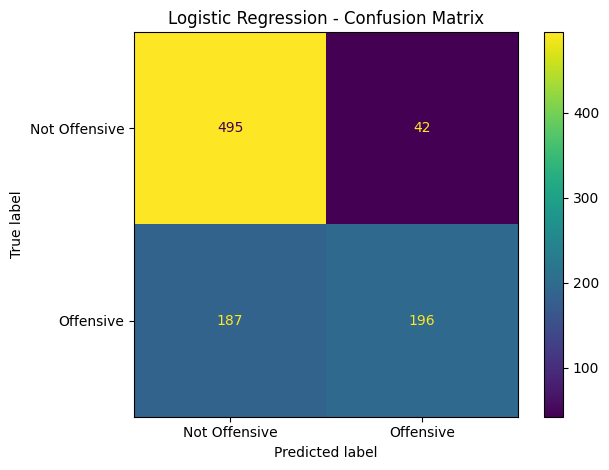

Confusion matrix saved to:
../results\confusion_matrices\logistic_regression.png


In [48]:
# Confusion Matrix for Naive Bayes

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(
    CONFUSION_MATRIX_DIR,"logistic_regression.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(CONFUSION_MATRIX_PATH)

In [49]:
# Save Naive Bayes test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: ../results\model_comparison.csv


In [50]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.52000
1,Logistic Regression - Test,0.751087,0.823529,0.511749,0.63124
